In [ ]:
from IPython.display import clear_output

! gh auth status > /dev/null || GH_PROMPT_DISABLED=1 gh auth login -w

# Clone and pip install alphagenome_research
! rm -rf ./alphagenome_research \
  && gh repo clone https://github.com/google-deepmind/alphagenome_research

! pip install ./alphagenome_research
clear_output()

In [ ]:
import os
from alphagenome.data import gene_annotation
from alphagenome.data import genome
from alphagenome.data import transcript as transcript_utils
from alphagenome.visualization import plot_components
from alphagenome_research.model import dna_model

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Flags to improve determinism.
os.environ['XLA_FLAGS'] = ' '.join([
    '--xla_gpu_deterministic_ops',
    '--xla_gpu_enable_scatter_determinism_expander=True',
    '--xla_gpu_enable_triton_gemm=False',
])

# Increase GPU and CPU memory to reduce out of memory errors.
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.9'

In [ ]:
# Download and load the pre-trained weights from Hugging Face
model = dna_model.create_from_huggingface('all_folds')
clear_output()
print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# import os
# import pandas as pd
# import numpy as np
# from alphagenome.data import genome

# print("Loading BED file from Google Drive...")

# # 1. Define the path to your Drive folder
# base_path = '/content/drive/MyDrive/Research/Ernst Lab/'
# bed_file_path = os.path.join(base_path, 'IHECRE00000001.4_18_ChromHMM.bed')

# # 2. Load the BED file
# # BED files are tab-separated. We assign column names for easy access.
# bed_df = pd.read_csv(bed_file_path, sep='\t', header=None,
#                      names=['chrom', 'start', 'end', 'state'])

# # 3. Define the exact interval to predict on
# # Using the start of chr10 based on your BED file snippet
# chrom = 'chr4'
# start_coord = 0
# end_coord = 2**20  # ~1.05 Mb (AlphaGenome's optimal window)

# interval = genome.Interval(chrom, start_coord, end_coord, strand='+')

# # 4. Rasterize the BED file into 200 bp bins
# bin_size = 200
# num_bins = int((end_coord - start_coord) / bin_size)

# bin_starts = np.arange(start_coord, end_coord, bin_size)
# bin_centers = bin_starts + (bin_size / 2)

# # Filter BED to just chr10 to speed up the mapping
# region_bed = bed_df[bed_df['chrom'] == chrom]

# print(f"Rasterizing {num_bins} bins...")
# actual_states = []

# for center in bin_centers:
#     match = region_bed[(region_bed['start'] <= center) & (region_bed['end'] > center)]
#     if not match.empty:
#         actual_states.append(match['state'].values[0])
#     else:
#         actual_states.append("Unknown")

# actual_states = np.array(actual_states)
# print(f"Generated {len(actual_states)} state labels.")

# print("\nRunning AlphaGenome Predictions...")
# # 5. Generate AlphaGenome Predictions
# predictions = model.predict_interval(
#     interval,
#     requested_outputs={
#         dna_model.OutputType.CHIP_HISTONE,
#         dna_model.OutputType.ATAC,
#         dna_model.OutputType.DNASE,
#     },
#     ontology_terms=['EFO:0001187'],
# )
# print("AlphaGenome predictions successfully generated!")

In [ ]:
from google.colab import drive
import os
import glob
import pandas as pd
import numpy as np
from alphagenome.data import genome

# Mount Drive
drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/Research/Ernst Lab/bed/'
bed_file_paths = glob.glob(os.path.join(base_path, '*.gz'))

if not bed_file_paths:
    print(f"No .gz files found in {base_path}. Please check your path.")

# ---------------------------------------------------------
# STEP 1: Generate AlphaGenome Features (FIXED WINDOW)
# ---------------------------------------------------------
chrom = 'chr4'

# Deep chromosome window, exactly 1,048,576 bp (2**20) wide
start_coord = 50_000_000
end_coord = start_coord + 2**20
bin_size = 200

interval = genome.Interval(chrom, start_coord, end_coord, strand='+')

print(f"Running AlphaGenome Predictions for {chrom}:{start_coord}-{end_coord}...")
# Assuming 'model' and 'dna_model' are defined elsewhere in your notebook
predictions = model.predict_interval(
    interval,
    requested_outputs={
        dna_model.OutputType.CHIP_HISTONE,
        dna_model.OutputType.ATAC,
        dna_model.OutputType.DNASE,
    },
    ontology_terms=['EFO:0001187'],
)

print("Flattening AlphaGenome tracks into Universal Consensus...")

output_h3k27ac = predictions.chip_histone.filter_tracks((predictions.chip_histone.metadata['histone_mark'] == 'H3K27ac').values)
output_h3k4me3 = predictions.chip_histone.filter_tracks((predictions.chip_histone.metadata['histone_mark'] == 'H3K4me3').values)
output_h3k4me1 = predictions.chip_histone.filter_tracks((predictions.chip_histone.metadata['histone_mark'] == 'H3K4me1').values)
output_h3k36me3 = predictions.chip_histone.filter_tracks((predictions.chip_histone.metadata['histone_mark'] == 'H3K36me3').values)
output_h3k27me3 = predictions.chip_histone.filter_tracks((predictions.chip_histone.metadata['histone_mark'] == 'H3K27me3').values)
output_h3k9me3 = predictions.chip_histone.filter_tracks((predictions.chip_histone.metadata['histone_mark'] == 'H3K9me3').values)

# Taking the mean creates a pan-cell-type average signal
atac_1d = predictions.atac.values.mean(axis=0)
dnase_1d = predictions.dnase.values.mean(axis=0)
h3k27ac_1d = output_h3k27ac.values.mean(axis=0)
h3k4me3_1d = output_h3k4me3.values.mean(axis=0)
h3k4me1_1d = output_h3k4me1.values.mean(axis=0)
h3k36me3_1d = output_h3k36me3.values.mean(axis=0)
h3k27me3_1d = output_h3k27me3.values.mean(axis=0)
h3k9me3_1d = output_h3k9me3.values.mean(axis=0)

ag_features = np.column_stack((
    atac_1d, dnase_1d,
    h3k27ac_1d, h3k4me3_1d, h3k4me1_1d,
    h3k36me3_1d, h3k27me3_1d, h3k9me3_1d
))

bin_starts = np.arange(start_coord, end_coord, bin_size)
bin_centers = bin_starts + (bin_size / 2)
bp_per_ag_bin = 128

ag_bin_indices = ((bin_centers - start_coord) / bp_per_ag_bin).astype(int)
ag_bin_indices = np.clip(ag_bin_indices, 0, len(atac_1d) - 1)

aligned_features = ag_features[ag_bin_indices]

# ---------------------------------------------------------
# STEP 2: Aggregate ALL BED Files into a Consensus (Majority Vote)
# ---------------------------------------------------------
print("\nAggregating labels across ALL Epigenomes...")
all_labels_matrix = []

for bed_file_path in bed_file_paths:
    file_name = os.path.basename(bed_file_path)
    print(f"Mapping {file_name}...")

    bed_df = pd.read_csv(bed_file_path, sep='\t', header=None,
                         names=['chrom', 'start', 'end', 'state'],
                         compression='gzip')

    region_bed = bed_df[bed_df['chrom'] == chrom]
    actual_states = np.full(len(bin_centers), "Unknown", dtype=object)

    for start, end, state in zip(region_bed['start'], region_bed['end'], region_bed['state']):
        mask = (bin_centers >= start) & (bin_centers < end)
        actual_states[mask] = state

    all_labels_matrix.append(actual_states)

# Convert to a 2D array: rows = cell types, columns = genomic bins
all_labels_matrix = np.array(all_labels_matrix)

print("\nCalculating consensus state (majority vote) per bin...")
# Using Pandas to handle string mode calculation
df_labels = pd.DataFrame(all_labels_matrix)
consensus_labels = df_labels.mode(axis=0).iloc[0].values

# Your dataset is now perfectly matched: 1 feature row per 1 consensus label
X_dataset = aligned_features
y_dataset = consensus_labels

print(f"✅ Master consensus dataset compiled! Total bins: {len(X_dataset)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running AlphaGenome Predictions for chr4:50000000-51048576...
Flattening AlphaGenome tracks into Universal Consensus...

Aggregating labels across ALL Epigenomes...
Mapping IHECRE00001984.1_18_ChromHMM.bed.gz...
Mapping IHECRE00001992.1_18_ChromHMM.bed.gz...
Mapping IHECRE00001990.1_18_ChromHMM.bed.gz...
Mapping IHECRE00001997.1_18_ChromHMM.bed.gz...
Mapping IHECRE00002005.1_18_ChromHMM.bed.gz...
Mapping IHECRE00002029.1_18_ChromHMM.bed.gz...
Mapping IHECRE00002048.1_18_ChromHMM.bed.gz...
Mapping IHECRE00002049.2_18_ChromHMM.bed.gz...
Mapping IHECRE00002058.1_18_ChromHMM.bed.gz...
Mapping IHECRE00002061.1_18_ChromHMM.bed.gz...
Mapping IHECRE00002063.1_18_ChromHMM.bed.gz...
Mapping IHECRE00002065.1_18_ChromHMM.bed.gz...
Mapping IHECRE00002071.1_18_ChromHMM.bed.gz...
Mapping IHECRE00002067.1_18_ChromHMM.bed.gz...
Mapping IHECRE00002075.1_18_ChromHMM.bed.gz...
M

TypeError: Argument `a` is not recognized as numeric. Support for input that cannot be coerced to a numeric array was deprecated in SciPy 1.9.0 and removed in SciPy 1.11.0. Please consider `np.unique`.

Removed 0 'Unknown' bins. Training on 8902614 valid bins.
Training on 7122091 samples, testing on 1780523 samples...

Calculating soft probabilities...

=== Soft Probabilities (First 10 Test Bins) ===
  Actual_State Predicted_State      10_EnhA2      11_EnhWk  12_ZNF/Rpts  \
0     18_Quies        18_Quies  5.433797e-07  6.964247e-07     0.000006   
1     18_Quies        18_Quies  5.433797e-07  6.964247e-07     0.000006   
2     18_Quies        18_Quies  5.433797e-07  6.964247e-07     0.000006   
3     18_Quies        18_Quies  5.433797e-07  6.964247e-07     0.000006   
4     18_Quies        18_Quies  5.433797e-07  6.964247e-07     0.000006   
5     18_Quies        18_Quies  5.433797e-07  6.964247e-07     0.000006   
6     18_Quies        18_Quies  5.433797e-07  6.964247e-07     0.000006   
7     18_Quies        18_Quies  5.433797e-07  6.964247e-07     0.000006   
8     18_Quies        18_Quies  5.433797e-07  6.964247e-07     0.000006   
9     18_Quies        18_Quies  5.433797e-07  6.9

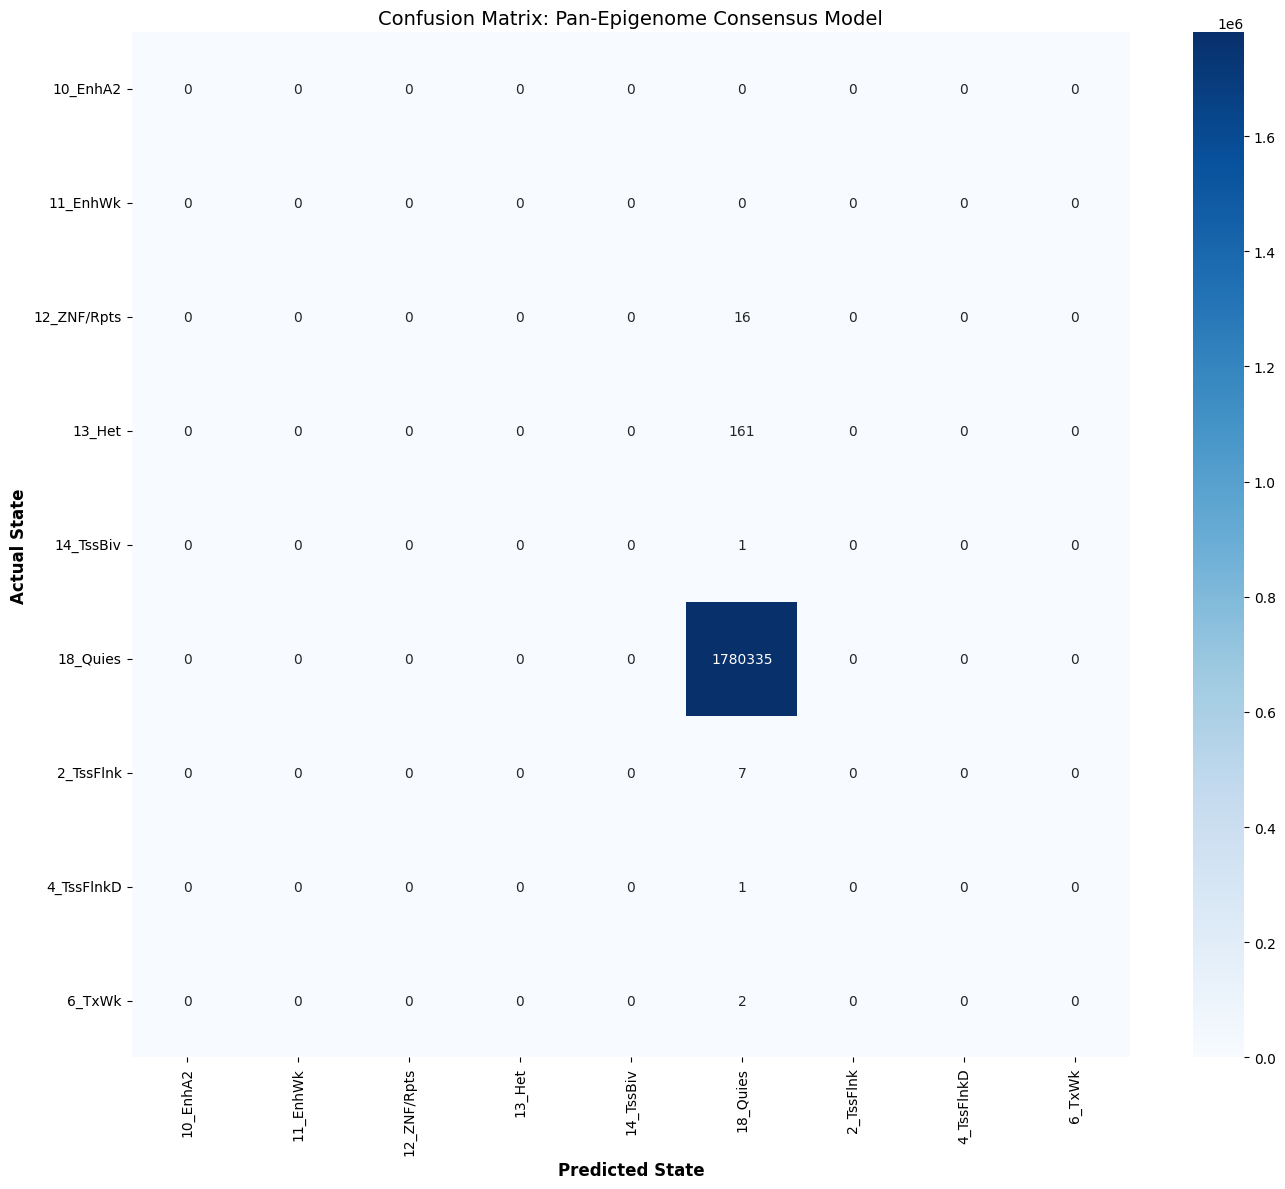

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---------------------------------------------------------
# STEP 3: Train the Consensus Model
# ---------------------------------------------------------
if len(X_dataset) != len(y_dataset):
    raise ValueError(f"Frameshift error: Features X have {len(X_dataset)} bins, labels y have {len(y_dataset)} bins.")

valid_indices = (y_dataset != "Unknown")
X_clean = X_dataset[valid_indices]
y_clean = y_dataset[valid_indices]

print(f"Removed {len(y_dataset) - len(y_clean)} 'Unknown' bins. Training on {len(y_clean)} valid bins.")

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

print(f"Training on {len(X_train)} samples, testing on {len(X_test)} samples...")

clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=20,
    random_state=42,
    # REMOVED class_weight='balanced' to prevent the model from over-predicting rare states
    class_weight=None,
    n_jobs=-1
)
clf.fit(X_train, y_train)

# ---------------------------------------------------------
# SOFT PROBABILITIES EXTRACTION
# ---------------------------------------------------------
print("\nCalculating soft probabilities...")

y_proba = clf.predict_proba(X_test)
state_names = clf.classes_
proba_df = pd.DataFrame(y_proba, columns=state_names)

y_pred = clf.predict(X_test)
proba_df.insert(0, 'Actual_State', y_test)
proba_df.insert(1, 'Predicted_State', y_pred)

print("\n=== Soft Probabilities (First 10 Test Bins) ===")
print(proba_df.head(10))

# ---------------------------------------------------------
# STEP 4: Plot Confusion Matrix
# ---------------------------------------------------------
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, zero_division=0))

labels = sorted(np.unique(y_clean))
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted State', fontweight='bold', fontsize=12)
plt.ylabel('Actual State', fontweight='bold', fontsize=12)
plt.title('Confusion Matrix: Pan-Epigenome Consensus Model', fontsize=14)

plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Calculating soft probabilities...

=== Soft Probabilities (First 10 Test Bins) ===
  Actual_State Predicted_State  10_EnhA2  11_EnhWk  12_ZNF/Rpts    13_Het  \
0  12_ZNF/Rpts     12_ZNF/Rpts  0.004645  0.036919     0.242401  0.086552   
1      9_EnhA1     12_ZNF/Rpts  0.004645  0.036919     0.242401  0.086552   
2       13_Het     12_ZNF/Rpts  0.004645  0.036919     0.242401  0.086552   
3       6_TxWk     12_ZNF/Rpts  0.004645  0.036919     0.242401  0.086552   
4  12_ZNF/Rpts     12_ZNF/Rpts  0.004645  0.036919     0.242401  0.086552   
5     18_Quies     12_ZNF/Rpts  0.004645  0.036919     0.242401  0.086552   
6     18_Quies     12_ZNF/Rpts  0.004645  0.036919     0.242401  0.086552   
7     18_Quies     12_ZNF/Rpts  0.004645  0.036919     0.242401  0.086552   
8         5_Tx     12_ZNF/Rpts  0.004645  0.036919     0.242401  0.086552   
9     18_Quies     12_ZNF/Rpts  0.004645  0.036919     0.242401  0.086552   

   14_TssBiv  15_EnhBiv  16_ReprPC  17_ReprPCWk  18_Quies    1_TssA 

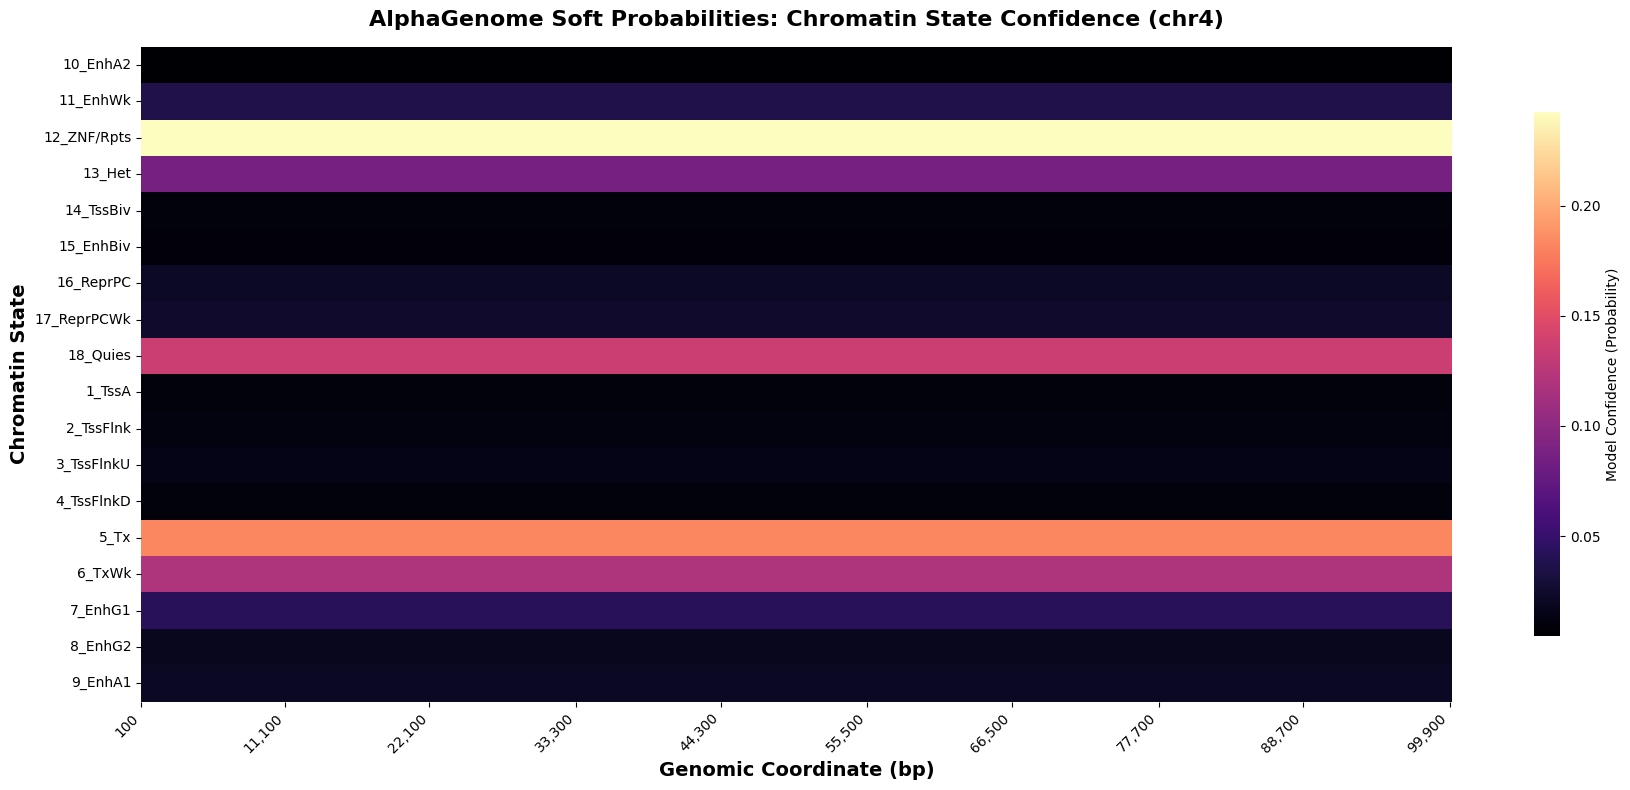

In [ ]:
import pandas as pd

print("\nCalculating soft probabilities...")

# 1. Generate the soft probability matrix
# This returns an array where each row is a bin, and each column is the probability of a specific state
y_proba = clf.predict_proba(X_test)

# 2. Map the probabilities to their actual state names
# clf.classes_ stores the exact order of the columns in y_proba
state_names = clf.classes_

# 3. Create a clean DataFrame for analysis
proba_df = pd.DataFrame(y_proba, columns=state_names)

# 4. Attach the actual and predicted labels so you can compare them side-by-side
proba_df.insert(0, 'Actual_State', y_test)
proba_df.insert(1, 'Predicted_State', y_pred)

# Display the first 10 rows to verify
print("\n=== Soft Probabilities (First 10 Test Bins) ===")
print(proba_df.head(10))

# Optional: Save this to a CSV for later analysis
# proba_df.to_csv('/content/drive/MyDrive/Research/Ernst Lab/soft_probabilities_output.csv', index=False)
# print("\nSaved soft probabilities to Google Drive.")

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\nGenerating soft probability heatmap...")

# 1. Define the genomic window to plot
# Plotting the whole chromosome at once can be too dense.
# Let's visualize a 500-bin window (100,000 bp).
start_idx = 0
window_size = 500
end_idx = start_idx + window_size

# 2. Slice the probabilities and coordinates for this specific window
plot_proba = y_proba[start_idx:end_idx]
plot_coords = bin_centers[start_idx:end_idx]

# 3. Set up the figure
plt.figure(figsize=(18, 8))

# 4. Generate the Heatmap
# We transpose (.T) the probability matrix so states are on the Y-axis and coordinates on the X-axis
ax = sns.heatmap(
    plot_proba.T,
    cmap='magma', # 'magma' or 'viridis' work incredibly well for probabilities
    cbar_kws={'label': 'Model Confidence (Probability)', 'shrink': 0.8},
    yticklabels=state_names
)

# 5. Format the X-axis to show actual genomic coordinates (bp) instead of bin indices
num_ticks = 10
tick_positions = np.linspace(0, window_size - 1, num_ticks, dtype=int)
tick_labels = [f"{int(plot_coords[i]):,}" for i in tick_positions]

plt.xticks(tick_positions, tick_labels, rotation=45, ha='right')

# 6. Add labels and title
plt.title(f'AlphaGenome Soft Probabilities: Chromatin State Confidence ({chrom})', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Genomic Coordinate (bp)', fontsize=14, fontweight='bold')
plt.ylabel('Chromatin State', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

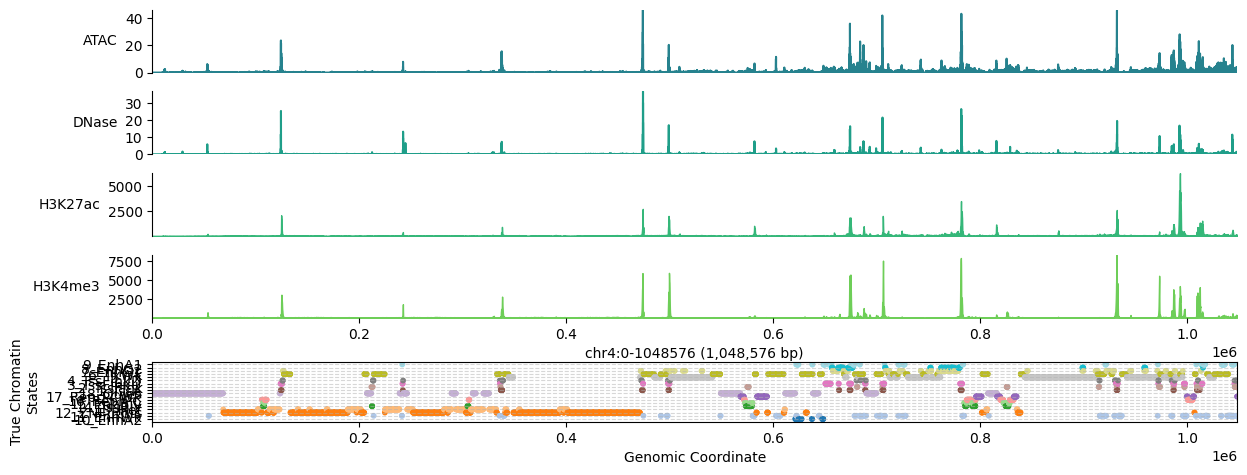

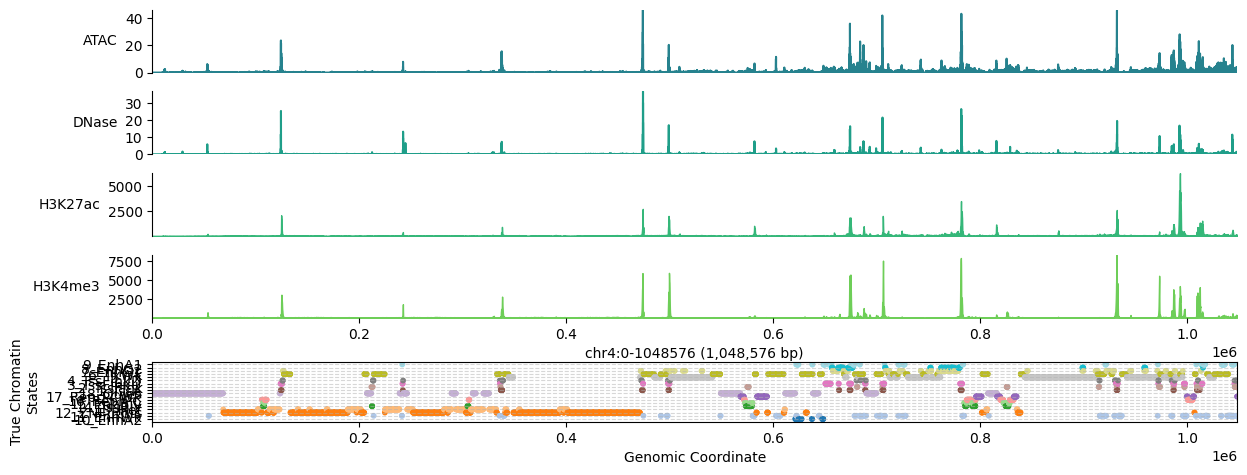

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display

def _get_colors_hex(cmap_name, n):
    cmap = matplotlib.colormaps[cmap_name]
    return [matplotlib.colors.rgb2hex(cmap(i)) for i in np.linspace(0, 1, n)][1:]

colors_hex = _get_colors_hex('viridis', 10)

# Filter out specific tracks often used for ChromHMM / Chromatin State derivation
output_h3k27ac = predictions.chip_histone.filter_tracks(
    (predictions.chip_histone.metadata['histone_mark'] == 'H3K27ac').values)
output_h3k4me3 = predictions.chip_histone.filter_tracks(
    (predictions.chip_histone.metadata['histone_mark'] == 'H3K4me3').values)

# Build the AlphaGenome plot components
components = [
    plot_components.Tracks(
        predictions.atac,
        ylabel_template='ATAC',
        track_colors=colors_hex[3],
        shared_y_scale=True,
    ),
    plot_components.Tracks(
        predictions.dnase,
        ylabel_template='DNase',
        track_colors=colors_hex[4],
        shared_y_scale=True,
    ),
    plot_components.Tracks(
        output_h3k27ac,
        ylabel_template='H3K27ac',
        filled=True,
        track_colors=colors_hex[5],
        shared_y_scale=True,
    ),
    plot_components.Tracks(
        output_h3k4me3,
        ylabel_template='H3K4me3',
        filled=True,
        track_colors=colors_hex[6],
        shared_y_scale=True,
    )
]

# Plot standard predictions
figure = plot_components.plot(
    components,
    interval=interval,
    fig_width=14,
    xlabel='{}:{}-{} ({:,.0f} bp)'.format(
        interval.chromosome, interval.start, interval.end, (interval.end - interval.start)
    ),
)

# Overlay your custom Chromatin States from the BED file
ax = figure.add_axes([0.125, -0.15, 0.775, 0.15]) # [left, bottom, width, height]

# Convert the text labels (e.g., '18_Quies') into numeric values for plotting.
unique_states = np.unique(actual_states)
state_to_int = {state: i for i, state in enumerate(unique_states)}
numeric_states = np.array([state_to_int[state] for state in actual_states])

# Generate X coordinates to match the length of our actual_states
x_coords = np.linspace(interval.start, interval.end, len(actual_states))

# Plot the scatter using the numeric states for coloring
ax.scatter(x_coords, numeric_states, c=numeric_states, cmap='tab20', s=10)

ax.set_ylabel("True Chromatin\nStates")
ax.set_xlabel("Genomic Coordinate")
ax.set_xlim(interval.start, interval.end)

# Set the y-axis to show the actual text labels instead of the numbers
ax.set_yticks(range(len(unique_states)))
ax.set_yticklabels(unique_states)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Force Colab to display the figure!
display(figure)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 1. Combine AlphaGenome predictions into a single feature matrix (X)
# Ensure you are concatenating along the feature axis, not flattening!
X = np.concatenate([
    predictions[dna_model.OutputType.CHIP_HISTONE],
    predictions[dna_model.OutputType.ATAC],
    predictions[dna_model.OutputType.DNASE]
], axis=1)

y = np.array(actual_states)

# 2. CRITICAL: The Data Alignment Check
# If this triggers, your AlphaGenome model outputs a different bin size than 200bp.
# You MUST change the 'bin_size' variable in your rasterization loop to match the model.
if len(X) != len(y):
    raise ValueError(f"Frameshift error: Features X have {len(X)} bins, but labels y have {len(y)} bins. Adjust your rasterization bin_size.")

# 3. CRITICAL: Filter out "Unknown" BEFORE training
valid_indices = (y != "Unknown")
X_clean = X[valid_indices]
y_clean = y[valid_indices]

print(f"Removed {len(y) - len(y_clean)} 'Unknown' bins. Training on {len(y_clean)} valid bins.")

# 4. Train/Test Split on the cleaned data
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

# 5. CRITICAL: Balance the Random Forest
clf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # Forces the model to penalize errors on rare classes appropriately
)

print("Training the classifier...")
clf.fit(X_train, y_train)

# 6. Predict and Evaluate
y_pred = clf.predict(X_test)

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, zero_division=0))

# 6. Plot Confusion Matrix
# Filter out 'Unknown' if you prefer to only plot known states
labels = sorted([label for label in np.unique(actual_states) if label != "Unknown"])

cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted State', fontweight='bold', fontsize=12)
plt.ylabel('Actual State', fontweight='bold', fontsize=12)
plt.title('Confusion Matrix: AlphaGenome Signals vs ChromHMM (80/20 Split)', fontsize=14)

# Rotate labels since you have 18 distinct ChromHMM states
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

TypeError: 'Output' object is not subscriptable

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

print("=== Overall Model Performance ===")
# Calculate overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%\n")

print("=== Detailed Classification Report ===")
# Generate the report for precision, recall, f1-score, and support
# zero_division=0 prevents warnings if a state was never predicted
report = classification_report(y_test, y_pred, zero_division=0)
print(report)